# 训练工程之术

> **难易：** 上 | **所需时辰：** 约三刻余

论文述其数理，此篇则述扩散模型训练中**真正要紧**之事：
噪声排程、损失加权、预测目标、EMA、精度之隐患，及常见故障之诊断。

此可谓**工程师之行军手册** —— 数月试验方得之知，凝于一篇。

**此篇所习：**
1. 噪声排程之择如何影响训练效率
2. 三种预测目标（epsilon、x0、v）及各自适用之时
3. 损失加权策略，以免浪费算力
4. EMA：每个扩散模型皆须之潜行品质提升
5. 扩散模型特有之混合精度隐患
6. 常见训练故障之诊断指南

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.diffusion import (
    linear_beta_schedule, cosine_beta_schedule, compute_alpha_bars, compute_snr,
    q_sample, SimpleDenoiser, make_swiss_roll, train_diffusion_2d,
    ddpm_sample_loop,
)
from mp_tutorial.diffusion_viz import draw_training_curves
from mp_tutorial.formatting import info_box
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
np.random.seed(42)
print("Setup complete.")

Setup complete.


---
## 一、训练工程何以为要

扩散训练**代价甚昂**。Stable Diffusion v1 约耗 150,000 A100 GPU 时。
于此规模，细微之工程抉择 —— 噪声排程、损失加权、预测目标 ——
可决良模型与数周虚耗算力之间之别。

此篇逐一阐述每一抉择点，附可于 CPU 运行之代码，
使汝先明其*理*，再行扩展。

In [2]:
info_box(
    "噪声排程之误可白废半数训练算力。"
    "预测目标不当可于高分辨率时致数值不稳。"
    "此非空谈 —— 皆实际大规模训练之教训。"
    "明此诸择，可省数周 GPU 之时。",
    title="何以为要"
)


---
## 二、噪声排程之设计

**噪声排程**者，定义每时步 $t$ 加噪几何也。
此乃扩散训练中**最为紧要**之超参数。

排程以 $\bar{\alpha}_t$（累积信号保留率）刻画，
控各时步之**信噪比（SNR）**：

$$\text{SNR}(t) = \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}$$

线性与余弦排程已于第零篇述之。
此处着重于高分辨率之**偏移排程**与近世模型所用之 **sigmoid 排程**。

In [3]:
# ── Noise Schedule Implementations ──────────────────────────

T = 1000

# 1. Standard schedules from mp_tutorial
betas_linear = linear_beta_schedule(T)
betas_cosine = cosine_beta_schedule(T)
ab_linear = compute_alpha_bars(betas_linear)
ab_cosine = compute_alpha_bars(betas_cosine)

# 2. Shifted cosine for high resolution (Chen et al., 2023)
def shifted_cosine_schedule(T, resolution=256, base_resolution=64, s=0.008):
    """Shift schedule based on resolution.
    
    High-res images have more pixel redundancy, so they need more noise
    to achieve the same perceptual corruption level. The shift factor
    scales the SNR accordingly.
    """
    shift = resolution / base_resolution  # e.g., 4x for 256px vs 64px
    # Start from cosine alpha_bars
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bars = (f / f[0])[1:].float()
    # Shift: convert to SNR, divide by shift factor, convert back
    snr = alpha_bars / (1 - alpha_bars).clamp(min=1e-10)
    shifted_snr = snr / shift
    alpha_bars_shifted = shifted_snr / (1 + shifted_snr)
    return alpha_bars_shifted

# 3. Sigmoid (log-linear) schedule
def sigmoid_schedule(T, start=-3, end=3):
    """Sigmoid schedule used in some recent models.
    
    Maps timesteps through a sigmoid, giving a smooth S-curve
    for alpha_bar that concentrates noise in the middle timesteps.
    """
    steps = torch.linspace(start, end, T)
    alpha_bars = torch.sigmoid(-steps)  # decreasing sigmoid
    # Normalize so alpha_bar[0] is close to 1
    alpha_bars = alpha_bars / alpha_bars[0]
    return alpha_bars

ab_shifted = shifted_cosine_schedule(T, resolution=256, base_resolution=64)
ab_sigmoid = sigmoid_schedule(T)

print("Alpha-bar at key timesteps:")
print(f"{'t':<8} {'Linear':<12} {'Cosine':<12} {'Shifted':<12} {'Sigmoid':<12}")
print("-" * 56)
for t_idx in [0, 100, 250, 500, 750, 999]:
    print(f"{t_idx:<8} {ab_linear[t_idx]:.4f}{'':>6} {ab_cosine[t_idx]:.4f}{'':>6} "
          f"{ab_shifted[t_idx]:.4f}{'':>6} {ab_sigmoid[t_idx]:.4f}")

Alpha-bar at key timesteps:
t        Linear       Cosine       Shifted      Sigmoid     
--------------------------------------------------------
0        0.9999       1.0000       0.9998       1.0000
100      0.8951       0.9716       0.8952       0.9624
250      0.5214       0.8459       0.5784       0.8580
500      0.0778       0.4923       0.1951       0.5241
750      0.0033       0.1432       0.0401       0.1908
999      0.0000       0.0000       0.0000       0.0498


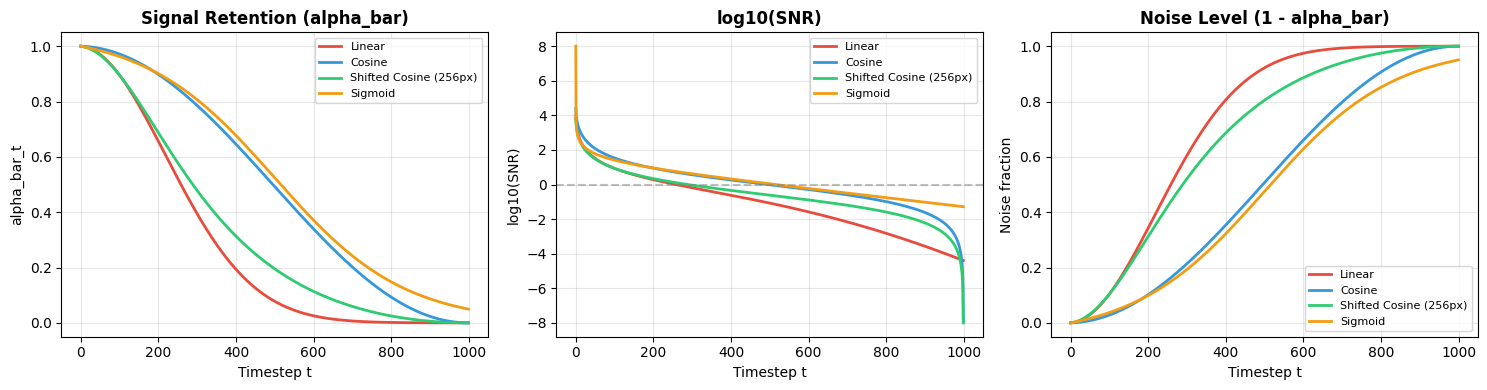

In [4]:
# ── Visualize: alpha_bar, log(SNR), noise level ───────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
timesteps = np.arange(T)

schedule_data = {
    "Linear": ab_linear,
    "Cosine": ab_cosine,
    "Shifted Cosine (256px)": ab_shifted,
    "Sigmoid": ab_sigmoid,
}
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

for (name, ab), color in zip(schedule_data.items(), colors):
    ab_np = ab.numpy()
    snr = ab_np / (1 - ab_np + 1e-8)

    axes[0].plot(timesteps, ab_np, label=name, color=color, lw=2)
    axes[1].plot(timesteps, np.log10(snr + 1e-8), label=name, color=color, lw=2)
    axes[2].plot(timesteps, 1 - ab_np, label=name, color=color, lw=2)

axes[0].set_title("Signal Retention (alpha_bar)", fontweight="bold")
axes[0].set_ylabel("alpha_bar_t"); axes[0].set_xlabel("Timestep t")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title("log10(SNR)", fontweight="bold")
axes[1].set_ylabel("log10(SNR)"); axes[1].set_xlabel("Timestep t")
axes[1].axhline(y=0, color="gray", ls="--", alpha=0.5)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_title("Noise Level (1 - alpha_bar)", fontweight="bold")
axes[2].set_ylabel("Noise fraction"); axes[2].set_xlabel("Timestep t")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
info_box(
    "<b>经验之则：</b>分辨率愈高，同等感知破坏所需噪声愈多。"
    "256x256 之图像像素为 64x64 之十六倍，冗余远多 —— "
    "须加相应更多之噪声方毁其结构。"
    "偏移余弦排程以分辨率比除 SNR 而自动处之。"
    "此乃 Chen 等（2023）之见解，近世高分辨率模型皆用偏移排程。",
    title="高分辨率之排程偏移"
)


---
## 三、预测目标：epsilon、x0 与 v

给定含噪样本 $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon$，
模型可被训练以预测不同之量。三者数学上等价
—— 彼此可互换 —— 然其**数值性质**大相径庭。

| 目标 | 公式 | 模型预测… |
|--------|---------|----------------------|
| **epsilon** | $\epsilon$ | 所加之噪声（原始 DDPM） |
| **x0** | $x_0$ | 净数据本身 |
| **v** | $\sqrt{\bar{\alpha}_t}\epsilon - \sqrt{1-\bar{\alpha}_t}x_0$ | 类速度之内插（Salimans & Ho, 2022） |

In [6]:
# ── Three Prediction Targets ───────────────────────────────

def compute_targets(x_0, noise, alpha_bar_t):
    """Compute all three prediction targets from the same (x_0, noise) pair."""
    sqrt_ab = torch.sqrt(alpha_bar_t)
    sqrt_1mab = torch.sqrt(1 - alpha_bar_t)

    # Noisy sample
    x_t = sqrt_ab * x_0 + sqrt_1mab * noise

    # Three equivalent targets
    target_eps = noise
    target_x0 = x_0
    target_v = sqrt_ab * noise - sqrt_1mab * x_0

    return x_t, target_eps, target_x0, target_v

# Recovery functions: from any prediction, recover the others
def x0_from_eps(x_t, eps_pred, alpha_bar_t):
    return (x_t - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

def eps_from_x0(x_t, x0_pred, alpha_bar_t):
    return (x_t - torch.sqrt(alpha_bar_t) * x0_pred) / torch.sqrt(1 - alpha_bar_t)

def x0_from_v(x_t, v_pred, alpha_bar_t):
    return torch.sqrt(alpha_bar_t) * x_t - torch.sqrt(1 - alpha_bar_t) * v_pred

# Demonstrate with a concrete example
torch.manual_seed(42)
x_0 = torch.randn(1, 3, 4, 4)  # a small "image"
noise = torch.randn_like(x_0)
ab = ab_cosine

print("Dynamic range of prediction targets across timesteps:")
print(f"{'t':<8} {'|eps| std':<14} {'|x0| std':<14} {'|v| std':<14}")
print("-" * 50)
for t_idx in [0, 50, 250, 500, 750, 999]:
    _, t_eps, t_x0, t_v = compute_targets(x_0, noise, ab[t_idx])
    print(f"{t_idx:<8} {t_eps.std():.4f}{'':>6} {t_x0.std():.4f}{'':>6} {t_v.std():.4f}")

print("\nKey insight: v-prediction std stays bounded at ALL timesteps.")
print("epsilon is constant; x0 is constant; but their GRADIENTS behave differently.")

Dynamic range of prediction targets across timesteps:
t        |eps| std      |x0| std       |v| std       
--------------------------------------------------


0        0.9580       1.0992       0.9585
50       0.9580       1.0992       0.9652
250      0.9580       1.0992       1.0040
500      0.9580       1.0992       1.0621
750      0.9580       1.0992       1.1003
999      0.9580       1.0992       1.0992

Key insight: v-prediction std stays bounded at ALL timesteps.
epsilon is constant; x0 is constant; but their GRADIENTS behave differently.


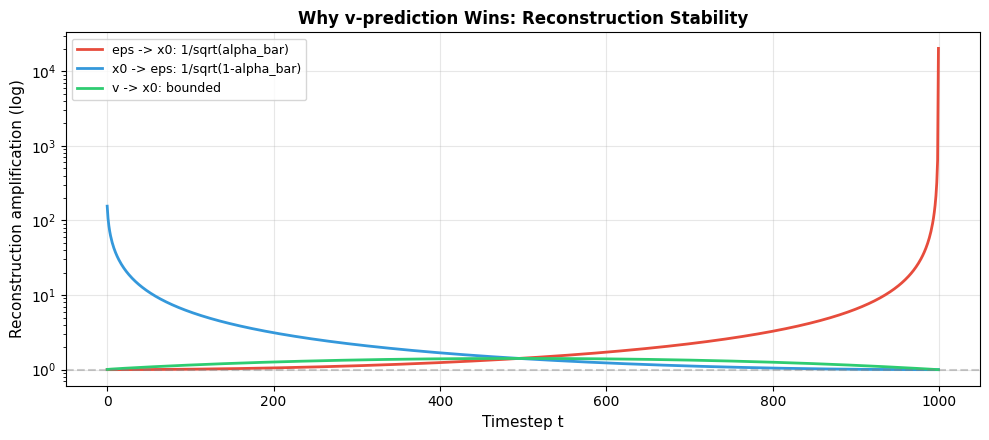

At t=999: eps->x0 amplification = 20291.3x
At t=999: v->x0 amplification   = 1.0x


In [7]:
# ── Why v-prediction is more stable ────────────────────────
# The issue is not the target magnitude, but the RECONSTRUCTION amplification.
# When predicting eps, recovering x0 requires dividing by sqrt(alpha_bar),
# which blows up at high noise (alpha_bar -> 0).

ab = ab_cosine
amplification_eps = 1.0 / torch.sqrt(ab)       # x0 recovery from eps
amplification_x0 = 1.0 / torch.sqrt(1 - ab)    # eps recovery from x0
# v-prediction: bounded reconstruction in both directions
amplification_v_to_x0 = torch.sqrt(ab) + torch.sqrt(1 - ab)  # upper bound

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(T), amplification_eps.numpy(), label="eps -> x0: 1/sqrt(alpha_bar)",
        color="#e74c3c", lw=2)
ax.plot(range(T), amplification_x0.numpy(), label="x0 -> eps: 1/sqrt(1-alpha_bar)",
        color="#3498db", lw=2)
ax.plot(range(T), amplification_v_to_x0.numpy(), label="v -> x0: bounded",
        color="#2ecc71", lw=2)

ax.set_yscale("log")
ax.set_xlabel("Timestep t", fontsize=11)
ax.set_ylabel("Reconstruction amplification (log)", fontsize=11)
ax.set_title("Why v-prediction Wins: Reconstruction Stability", fontweight="bold")
ax.axhline(y=1, color="gray", ls="--", alpha=0.4)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("At t=999: eps->x0 amplification = {:.1f}x".format(amplification_eps[-1].item()))
print("At t=999: v->x0 amplification   = {:.1f}x".format(amplification_v_to_x0[-1].item()))

In [8]:
# ── Train with each prediction target on Swiss roll ───────

data = make_swiss_roll(n_points=2000, seed=42)
T_toy = 200
betas_toy = cosine_beta_schedule(T_toy)
ab_toy = compute_alpha_bars(betas_toy)

def train_with_target(target_type, n_epochs=150, lr=3e-4):
    """Train a denoiser with the specified prediction target."""
    torch.manual_seed(42)
    model = SimpleDenoiser(data_dim=2, hidden=128, n_classes=0, time_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(n_epochs):
        t = torch.randint(0, T_toy, (len(data),))
        x_t, noise = q_sample(data, t, ab_toy)

        pred = model(x_t, t)

        # Compute target based on type
        if target_type == "eps":
            target = noise
        elif target_type == "x0":
            target = data
        elif target_type == "v":
            abar_t = ab_toy[t].unsqueeze(-1)
            target = torch.sqrt(abar_t) * noise - torch.sqrt(1 - abar_t) * data
        
        loss = F.mse_loss(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

print("Training with each prediction target (this takes ~15 seconds)...")
losses_eps = train_with_target("eps")
print("  eps-prediction done.")
losses_x0 = train_with_target("x0")
print("  x0-prediction done.")
losses_v = train_with_target("v")
print("  v-prediction done.")

Training with each prediction target (this takes ~15 seconds)...


  eps-prediction done.


  x0-prediction done.


  v-prediction done.


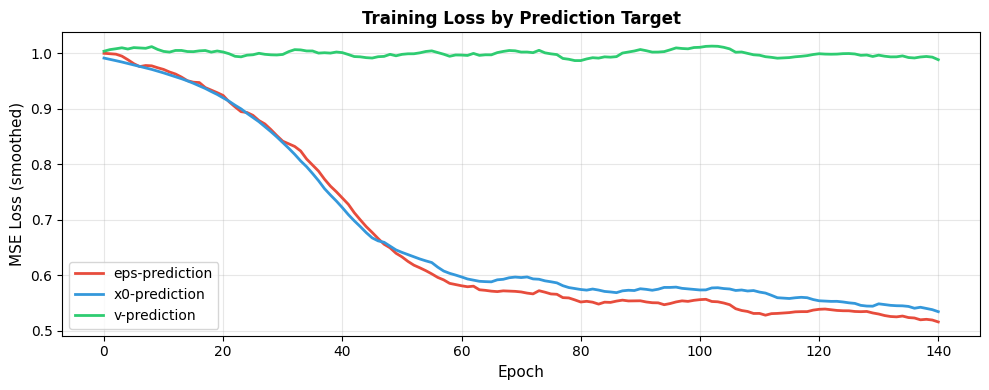

Note: The absolute loss values differ because the targets have different scales.
What matters is convergence speed and final sample quality, not raw loss numbers.


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

window = 10
for losses, name, color in [
    (losses_eps, "eps-prediction", "#e74c3c"),
    (losses_x0, "x0-prediction", "#3498db"),
    (losses_v, "v-prediction", "#2ecc71"),
]:
    smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
    ax.plot(smoothed, label=name, color=color, lw=2)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss (smoothed)", fontsize=11)
ax.set_title("Training Loss by Prediction Target", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: The absolute loss values differ because the targets have different scales.")
print("What matters is convergence speed and final sample quality, not raw loss numbers.")

In [10]:
info_box(
    "<b>v-prediction</b> 已成近世模型（Stable Diffusion XL、Imagen Video）之标准，缘由有三：<br>"
    "一、<b>有界之重建</b> —— 自 v 恢复 x0 时误差放大不逾约 1.4 倍，"
    "而 eps-prediction 于高噪声时可放大百倍以上。<br>"
    "二、<b>平滑之内插</b> —— 低噪声时 v 近似 -x0（净信号），"
    "高噪声时 v 近似 epsilon（噪声）。模型自然过渡于二域之间。<br>"
    "三、<b>利于高分辨率与视频</b> —— 彼处高噪声域数值挑战尤甚。",
    title="v-prediction 何以胜出"
)


---
## 四、损失加权：基于 SNR 之策略

若均匀采样时步，则模型于各噪声水平均花同等之力。
然此甚为浪费：

- **高噪声（t 大时）：** 图像几毁殆尽。模型几同猜测数据集均值。训练信号甚微。
- **低噪声（t 小时）：** 细节紧要，然任务亦较易。

要旨在：**以各时步之难度为权**，使学习信号于排程间均衡。

四种策略：
- **均匀**：各时步等权（基准）
- **SNR 加权**：权重正比于信噪比
- **Min-SNR-gamma**：于 gamma 处截取 SNR 权重，防简易时步过度主宰
- **P2（感知优先）**：增中等噪声时步之权，彼处感知品质最为紧要

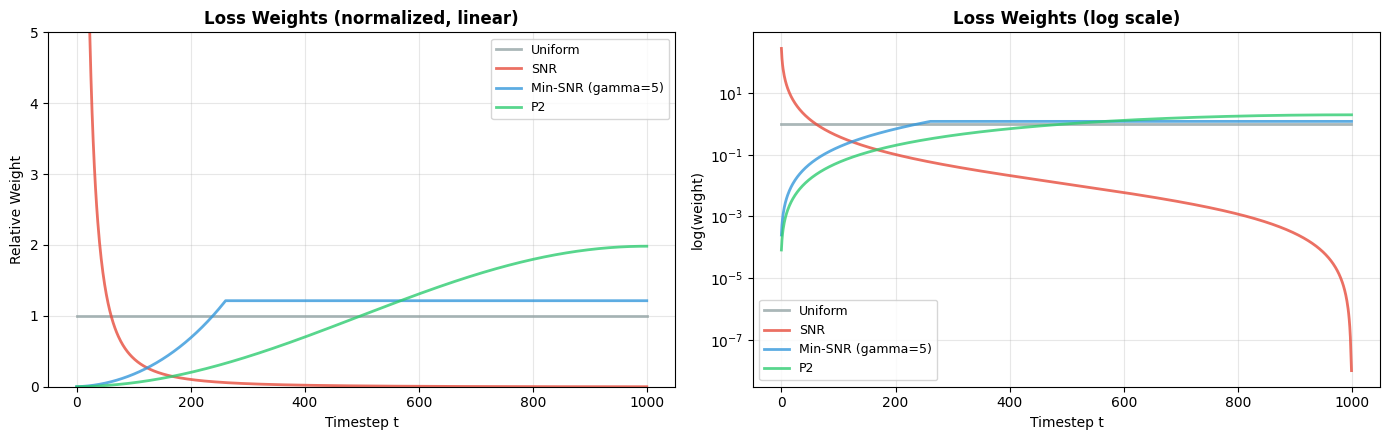

In [11]:
# ── Loss Weighting Strategies ──────────────────────────────

T = 1000
betas = cosine_beta_schedule(T)
alpha_bars = compute_alpha_bars(betas)
snr = compute_snr(alpha_bars)

# Four weighting strategies
uniform_w = torch.ones(T)
snr_w = snr.clone()
min_snr_w = torch.clamp(snr, max=5.0) / snr        # Min-SNR gamma=5
p2_w = 1.0 / (1.0 + snr)                            # Simplified P2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
timesteps = np.arange(T)
items = [
    ("Uniform", uniform_w, "#95a5a6"),
    ("SNR", snr_w, "#e74c3c"),
    ("Min-SNR (gamma=5)", min_snr_w, "#3498db"),
    ("P2", p2_w, "#2ecc71"),
]

for name, w, color in items:
    w_norm = w / w.mean()  # normalize for comparison
    axes[0].plot(timesteps, w_norm.numpy(), label=name, color=color, lw=2, alpha=0.8)
    axes[1].semilogy(timesteps, w_norm.numpy() + 1e-8, label=name, color=color, lw=2, alpha=0.8)

axes[0].set_title("Loss Weights (normalized, linear)", fontweight="bold")
axes[0].set_xlabel("Timestep t"); axes[0].set_ylabel("Relative Weight")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 5)

axes[1].set_title("Loss Weights (log scale)", fontweight="bold")
axes[1].set_xlabel("Timestep t"); axes[1].set_ylabel("log(weight)")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Training with different loss weightings (~20 seconds)...


  Uniform done.


  Min-SNR done.


  P2 done.


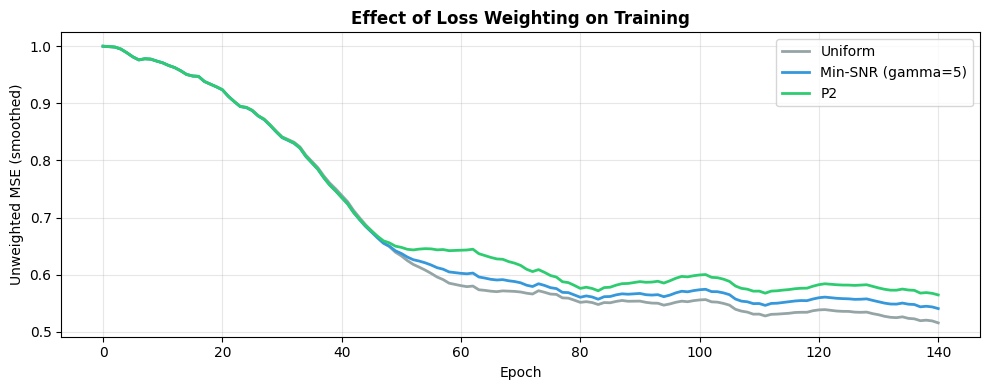

In [12]:
# ── Train with different weightings ────────────────────────

data = make_swiss_roll(n_points=2000, seed=42)
T_toy = 200
betas_toy = cosine_beta_schedule(T_toy)
ab_toy = compute_alpha_bars(betas_toy)
snr_toy = compute_snr(ab_toy)

def train_weighted(weight_fn, n_epochs=150, lr=3e-4):
    """Train with a per-timestep loss weighting function."""
    torch.manual_seed(42)
    model = SimpleDenoiser(data_dim=2, hidden=128, n_classes=0, time_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(n_epochs):
        t = torch.randint(0, T_toy, (len(data),))
        x_t, noise = q_sample(data, t, ab_toy)
        pred = model(x_t, t)
        
        # Per-sample weighting
        w = weight_fn(t)
        per_sample_loss = ((pred - noise) ** 2).mean(dim=-1)
        loss = (w * per_sample_loss).mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(per_sample_loss.mean().item())  # log unweighted for comparison
    return losses

print("Training with different loss weightings (~20 seconds)...")
losses_uniform = train_weighted(lambda t: torch.ones_like(t, dtype=torch.float32))
print("  Uniform done.")
losses_minsnr = train_weighted(lambda t: torch.clamp(snr_toy[t], max=5.0) / snr_toy[t].clamp(min=1e-6))
print("  Min-SNR done.")
losses_p2 = train_weighted(lambda t: 1.0 / (1.0 + snr_toy[t]))
print("  P2 done.")

fig, ax = plt.subplots(figsize=(10, 4))
window = 10
for losses, name, color in [
    (losses_uniform, "Uniform", "#95a5a6"),
    (losses_minsnr, "Min-SNR (gamma=5)", "#3498db"),
    (losses_p2, "P2", "#2ecc71"),
]:
    smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
    ax.plot(smoothed, label=name, color=color, lw=2)

ax.set_xlabel("Epoch"); ax.set_ylabel("Unweighted MSE (smoothed)")
ax.set_title("Effect of Loss Weighting on Training", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
info_box(
    "<b>Min-SNR-gamma</b>（Hang 等，2023）乃当下推荐之默认。"
    "其于 gamma（通常为 5）处截取最大权重，使简易之低噪声时步"
    "不至主宰损失，同时相对高噪声时步仍获更多权重 ——"
    "彼处模型难胜于随机。<br><br>"
    "实践中，min-SNR（gamma=5）于多数数据集与架构上"
    "收敛更快，FID 分数更优。",
    title="推荐：Min-SNR（gamma=5）"
)


---
## 五、EMA：指数移动平均

**指数移动平均（EMA）** 于训练中维持模型权重之缓更副本。
推断时用 EMA 权重而非原始训练权重。

$$\theta_{\text{EMA}} \leftarrow \beta \cdot \theta_{\text{EMA}} + (1 - \beta) \cdot \theta_{\text{train}}$$

其中 $\beta$（衰减率）通常为 0.9999。此法平滑嘈杂之梯度更新，
可恒常产出更佳之样本。

可以此喻之：训练途中所历诸模型之**滑动均值**，
近者权重较重。

In [14]:
# ── EMA Implementation ─────────────────────────────────────

class EMA:
    """Exponential Moving Average of model parameters.
    
    Usage:
        ema = EMA(model, decay=0.9999)
        for batch in dataloader:
            loss = train_step(model, batch)
            ema.update(model)       # after each optimizer step
        ema.apply(model)            # swap in EMA weights for inference
    """
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = {name: p.clone().detach()
                       for name, p in model.named_parameters()}
        self.step_count = 0

    def update(self, model):
        """Update EMA weights. Call after each optimizer.step()."""
        self.step_count += 1
        # Optional warmup: ramp decay from 0 to target
        decay = min(self.decay, (1 + self.step_count) / (10 + self.step_count))
        with torch.no_grad():
            for name, p in model.named_parameters():
                self.shadow[name].mul_(decay).add_(p.data, alpha=1 - decay)

    def apply(self, model):
        """Copy EMA weights into the model for inference."""
        with torch.no_grad():
            for name, p in model.named_parameters():
                p.data.copy_(self.shadow[name])

    def state_dict(self):
        return {"shadow": self.shadow, "decay": self.decay, "step_count": self.step_count}

# Quick demonstration
model_demo = nn.Linear(10, 10)
ema = EMA(model_demo, decay=0.9999)
print(f"EMA created with decay={ema.decay}")
print(f"Tracking {len(ema.shadow)} parameter tensors")
print(f"Shadow weight norm: {ema.shadow['weight'].norm():.4f}")

EMA created with decay=0.9999
Tracking 2 parameter tensors
Shadow weight norm: 1.8020


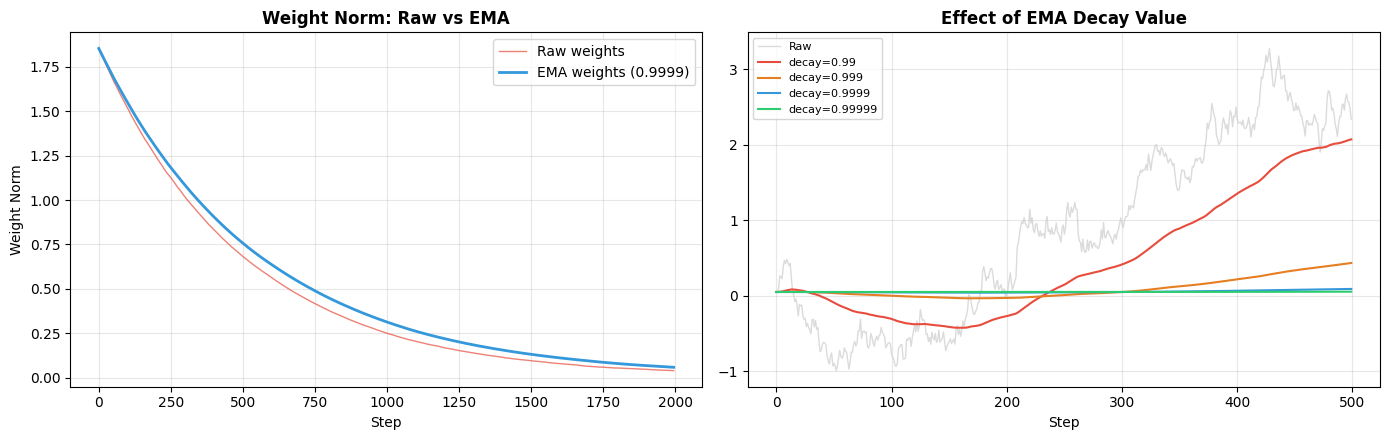

In [15]:
# ── EMA smoothing effect ───────────────────────────────────

torch.manual_seed(42)
model_raw = nn.Linear(10, 10)
model_ema_copy = nn.Linear(10, 10)
model_ema_copy.load_state_dict(model_raw.state_dict())
ema = EMA(model_raw, decay=0.9999)

optimizer = torch.optim.SGD(model_raw.parameters(), lr=0.01)

raw_norms = []
ema_norms = []

for step in range(2000):
    x = torch.randn(32, 10)
    target = torch.randn(32, 10) * 0.3
    loss = F.mse_loss(model_raw(x), target)
    loss.backward()

    # Add gradient noise to simulate stochastic training
    with torch.no_grad():
        for p in model_raw.parameters():
            p.grad += torch.randn_like(p.grad) * 0.005

    optimizer.step()
    optimizer.zero_grad()
    ema.update(model_raw)

    if step % 5 == 0:
        raw_norms.append(model_raw.weight.data.norm().item())
        ema_norms.append(ema.shadow['weight'].norm().item())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
steps_x = np.arange(len(raw_norms)) * 5

axes[0].plot(steps_x, raw_norms, label="Raw weights", color="#e74c3c", alpha=0.7, lw=1)
axes[0].plot(steps_x, ema_norms, label="EMA weights (0.9999)", color="#3498db", lw=2)
axes[0].set_title("Weight Norm: Raw vs EMA", fontweight="bold")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Weight Norm")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Show different decay values on a noisy signal
np.random.seed(42)
noisy = np.cumsum(np.random.randn(500) * 0.1) + np.linspace(0, 2, 500)
axes[1].plot(noisy, label="Raw", color="#ccc", lw=1, alpha=0.7)
for decay, color in [(0.99, "#e74c3c"), (0.999, "#e67e22"),
                      (0.9999, "#3498db"), (0.99999, "#2ecc71")]:
    ema_sig = np.zeros_like(noisy)
    ema_sig[0] = noisy[0]
    for i in range(1, len(noisy)):
        ema_sig[i] = decay * ema_sig[i-1] + (1 - decay) * noisy[i]
    axes[1].plot(ema_sig, label=f"decay={decay}", color=color, lw=1.5)
axes[1].set_title("Effect of EMA Decay Value", fontweight="bold")
axes[1].set_xlabel("Step"); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
info_box(
    "<b>EMA 当避之患：</b><br>"
    "一、<b>起用过早</b> —— 随机权重之 EMA 仍为随机。宜暖身："
    "前约千步将衰减自 0 渐增至 0.9999。<br>"
    "二、<b>衰减率不当</b> —— 0.9999 为常规。0.999 过于灵敏（样本嘈杂），"
    "0.99999 则过于迟缓（滞后改进数千步）。<br>"
    "三、<b>忘换权重</b> —— 推断时必用 EMA 权重。"
    "原始训练权重所产样本明显不如。<br>"
    "四、<b>未存 EMA 状态</b> —— 检查点中须含 EMA 影子权重。"
    "失之则失最优模型。",
    title="EMA：扩散模型之必备"
)


---
## 六、混合精度之隐患

混合精度训练（FP16 或 BF16）于加速不可或缺，然扩散模型
有其特有之数值风险，非他模型类型所有。

核心之患：扩散模型处理极近零之值
（噪声预测以 0 为中心、alpha_bar 值近 0 或 1），
恰为 FP16 力有不逮之处。

In [17]:
# ── The FP16 Problem ───────────────────────────────────────
# At low noise (t close to 0), (1 - alpha_bar) is tiny.
# At high noise (t close to T), alpha_bar is tiny.
# Both are dangerous in FP16.

ab = compute_alpha_bars(cosine_beta_schedule(1000))

print("Precision comparison at critical timesteps:")
print(f"{'t':<6} {'1-ab (FP32)':<20} {'1-ab (FP16)':<20} {'Relative Error':<16}")
print("-" * 62)
for t in [0, 1, 2, 5, 10, 50, 100, 500]:
    val32 = (1 - ab[t]).item()
    val16 = (1 - ab[t].half()).item()
    if val32 > 0:
        err = abs(val32 - val16) / val32
        print(f"{t:<6} {val32:<20.10f} {val16:<20.10f} {err:<16.4%}")

print()
print("FP16 vs BF16 key properties:")
print("  FP16: 5 exponent bits, 10 mantissa  -> range ~6e-8  to 65504")
print("  BF16: 8 exponent bits,  7 mantissa  -> range ~1e-38 to 3e38")
print("  FP16 has more precision but MUCH less dynamic range")

Precision comparison at critical timesteps:
t      1-ab (FP32)          1-ab (FP16)          Relative Error  
--------------------------------------------------------------
0      0.0000413060         0.0000000000         100.0000%       
1      0.0000874400         0.0000000000         100.0000%       
2      0.0001384616         0.0000000000         100.0000%       
5      0.0003205538         0.0004882812         52.3243%        
10     0.0007211566         0.0004882812         32.2919%        
50     0.0082753301         0.0083007812         0.3076%         
100    0.0284243822         0.0283203125         0.3661%         
500    0.5077149868         0.5078125000         0.0192%         

FP16 vs BF16 key properties:
  FP16: 5 exponent bits, 10 mantissa  -> range ~6e-8  to 65504
  BF16: 8 exponent bits,  7 mantissa  -> range ~1e-38 to 3e38
  FP16 has more precision but MUCH less dynamic range


In [18]:
# ── Demonstrate gradient underflow ─────────────────────────

torch.manual_seed(42)
eps = torch.randn(10000)

# In FP16, values very close to zero can underflow
eps_fp16 = eps.half()
eps_bf16 = eps.bfloat16()

zeros_fp16 = (eps_fp16 == 0).sum().item()
zeros_bf16 = (eps_bf16 == 0).sum().item()

print("Noise prediction values near zero:")
print(f"  FP32: min |value| = {eps.abs().min():.6e}")
print(f"  FP16: values collapsed to zero: {zeros_fp16} / {len(eps)}")
print(f"  BF16: values collapsed to zero: {zeros_bf16} / {len(eps)}")

# The real problem: loss computation
ab_low = ab[1]  # very low noise
noise_scale = torch.sqrt(1 - ab_low)
print(f"\nAt t=1: noise_scale = sqrt(1 - alpha_bar) = {noise_scale.item():.8f}")
print(f"  In FP16: {noise_scale.half().item():.8f}")
print(f"  In BF16: {noise_scale.bfloat16().item():.8f}")
print()
print("If noise_scale underflows to 0 in FP16:")
print("  -> x_t = sqrt(ab)*x_0 + 0*noise = x_0  (noise disappears!)")
print("  -> model receives ZERO gradient for fine detail reconstruction")
print("  -> generated images are blurry at fine scales")

Noise prediction values near zero:
  FP32: min |value| = 6.886041e-05
  FP16: values collapsed to zero: 0 / 10000
  BF16: values collapsed to zero: 0 / 10000

At t=1: noise_scale = sqrt(1 - alpha_bar) = 0.00935094
  In FP16: 0.00935364
  In BF16: 0.00933838

If noise_scale underflows to 0 in FP16:
  -> x_t = sqrt(ab)*x_0 + 0*noise = x_0  (noise disappears!)
  -> model receives ZERO gradient for fine detail reconstruction
  -> generated images are blurry at fine scales


In [19]:
info_box(
    "扩散训练<b>必用 BF16</b>（若硬件支持：A100、H100、RTX 4090）。"
    "BF16 与 FP32 动态范围同，然内存仅半。<br><br>"
    "若不得已用 FP16（旧 GPU 如 V100）：<br>"
    "- 用激进之损失缩放（起始 2^16，动态缩放）<br>"
    "- 噪声排程之算术保于 FP32<br>"
    "- 每约百步检查 NaN 梯度<br>"
    "- 除法前将 alpha_bar 截至 [1e-5, 1-1e-5]<br><br>"
    "推断时之精度考量，参见"
    "<a href='../../en/inference/05-quantization-pruning.ipynb'>量化与剪枝</a>。",
    title="精度法则：BF16 优于 FP16"
)


---
## 七、常见训练故障与调试

此乃全篇最具实用之节 —— 遇事不顺时之诊断参考。
每一条目皆出于实际大规模训练之失败。

In [20]:
info_box(
    "<b>诊断清单：</b><br><br>"
    "<b>损失变 NaN</b><br>"
    "原因：FP16 下溢或学习率过高<br>"
    "修复：换 BF16。学习率降十倍。加梯度裁剪（max_norm=1.0）。<br><br>"
    "<b>损失早期即平台，终不下降</b><br>"
    "原因：噪声排程不匹配或模型过小<br>"
    "修复：试余弦排程。增模型容量。查数据归一化为 [-1,1]。<br><br>"
    "<b>生成之样本模糊</b><br>"
    "原因：未用 EMA，或低噪声时步权重不足<br>"
    "修复：用 EMA（decay=0.9999）。用 min-SNR 加权。训更久。<br><br>"
    "<b>模式坍缩（多样性低）</b><br>"
    "原因：CFG dropout 过低，或批大小过小<br>"
    "修复：CFG 训练中设 p_uncond=0.1-0.2。增批大小。<br><br>"
    "<b>生成图像色偏</b><br>"
    "原因：数据归一化不匹配（如 [0,1] 与 [-1,1]）<br>"
    "修复：确数据归一至 [-1,1]。查潜扩散之 VAE 解码器。<br><br>"
    "<b>训练发散（损失爆炸）</b><br>"
    "原因：特定时步梯度爆炸<br>"
    "修复：梯度裁剪。用 v-prediction。查 FP16 溢出。",
    title="故障诊断参考"
)


In [21]:
# ── Training Health Check ──────────────────────────────────

def training_health_check(losses, window=100):
    """Quick diagnostics on a training loss history.
    
    Run this periodically during training to catch problems early.
    """
    losses = np.array(losses)
    print("=== Training Health Check ===")
    print(f"Total steps: {len(losses)}")
    
    # Check for NaN
    nan_mask = np.isnan(losses)
    if nan_mask.any():
        first_nan = np.argmax(nan_mask)
        print(f"FAIL: NaN detected at step {first_nan}")
        print(f"  -> Check precision (use BF16) and learning rate")
        return False
    
    # Recent statistics
    recent = losses[-window:] if len(losses) >= window else losses
    print(f"Recent avg loss:   {np.mean(recent):.6f}")
    print(f"Recent std loss:   {np.std(recent):.6f}")
    
    # Trend
    if len(losses) >= 2 * window:
        prev = losses[-2*window:-window]
        improvement = (np.mean(prev) - np.mean(recent)) / np.mean(prev)
        if improvement > 0.01:
            print(f"Trend: decreasing ({improvement:.1%} improvement)")
        elif improvement < -0.01:
            print(f"WARNING: loss INCREASING ({-improvement:.1%} worse)")
            print(f"  -> Reduce learning rate or check for data issues")
        else:
            print(f"Trend: plateaued (< 1% change)")
    
    # Stability
    cv = np.std(recent) / (np.mean(recent) + 1e-8)
    if cv > 0.5:
        print(f"WARNING: High variance (CV={cv:.2f})")
        print(f"  -> Training may be unstable. Try gradient clipping or lower LR")
    else:
        print(f"Stability: good (CV={cv:.2f})")
    
    print("=== Check Complete ===")
    return True

# Demo with our earlier training losses
print("Checking eps-prediction training:")
training_health_check(losses_eps, window=30)
print()

# Demo with a deliberately bad run
bad_losses = list(np.random.randn(200) * 0.5 + 1.0)
bad_losses[150] = float('nan')
print("Checking a problematic training run:")
training_health_check(bad_losses, window=30)

Checking eps-prediction training:
=== Training Health Check ===
Total steps: 150
Recent avg loss:   0.528047
Recent std loss:   0.015730
Trend: decreasing (3.5% improvement)
Stability: good (CV=0.03)
=== Check Complete ===

Checking a problematic training run:
=== Training Health Check ===
Total steps: 200
FAIL: NaN detected at step 150
  -> Check precision (use BF16) and learning rate


False

---
## 八、总括

此篇述扩散训练中成败攸关之工程抉择：

| 题目 | 要旨 |
|-------|-------------|
| **噪声排程** | 余弦优于线性。高分辨率须偏移。Sigmoid 以平滑过渡。 |
| **预测目标** | 高分辨率用 v-prediction；小图用 eps。三者等价。 |
| **损失加权** | Min-SNR（gamma=5）为当下最优默认。 |
| **EMA** | 必用之。衰减 0.9999，前约千步暖身。 |
| **精度** | 恒用 BF16。FP16 于低噪声时下溢 —— 暗损品质。 |
| **调试** | 用诊断清单。监损失趋势。早查 NaN。 |

### 要文

- **EDM** —— [Elucidating the Design Space of Diffusion-Based Generative Models](https://arxiv.org/abs/2206.00364) (Karras et al., 2022)：系统化排程与加权之择
- **v-prediction** —— [Progressive Distillation for Fast Sampling](https://arxiv.org/abs/2202.00512) (Salimans & Ho, 2022)
- **偏移排程** —— [Simple diffusion: End-to-end diffusion for high resolution images](https://arxiv.org/abs/2301.11093) (Hoogeboom et al., 2023)
- **Min-SNR** —— [Efficient Diffusion Training via Min-SNR Weighting](https://arxiv.org/abs/2303.09556) (Hang et al., 2023)
- **P2 加权** —— [Perception Prioritized Training of Diffusion Models](https://arxiv.org/abs/2204.00227) (Choi et al., 2022)

### 次篇

**[七 —— 微调与适配](07-finetuning-adaptation.ipynb)**：ControlNet、LoRA、DreamBooth，及实用微调之方。